# LAB 02: NAVIE BAYES CLASSIFICATION
## A. Phuong phap Gaussian navie bayes voi du lieu lien tuc 

### vi du 1. Phan loai bo du lieu hoa IRIS
- ộ dữ liệu hoa IRIS có thể lấy từ link sau (tệp excel csv): http://archive.ics.uci.edu/ml/datasets/Iris (hoặc
tệp Iris.data – dạng văn bản kèm theo bài thực hành).
- Do dữ liệu vào là số thực, vì vậy chúng ta sẽ phải dùng phương pháp Gaussian Naïve Bayes (tự xem
lại phần lý thuyết).
- Để đơn giản trước hết ta chỉ căn cứ vào độ dài cánh hoa để phân loại. Các bước tính toán theo lý thuyết
(sử dụng phương pháp ước lượng hợp lý cực đại – MLE):
- Chúng ta có thể giải bằng 02 thư viện, numpy và scikit-learning. Chú ý bộ dữ liệu IRIS khá chuẩn
mực trong việc sử dụng làm minh họa cho bài toán classification, do đó có thể load từ thư viện của
python.

In [1]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score
import matplotlib.colors as colors
import matplotlib.pyplot as plt
import seaborn as sns 
import itertools 
from scipy.stats import norm 
import scipy.stats
from sklearn.naive_bayes import GaussianNB 
%matplotlib inline
sns.set()

#### Su dung Numpy 

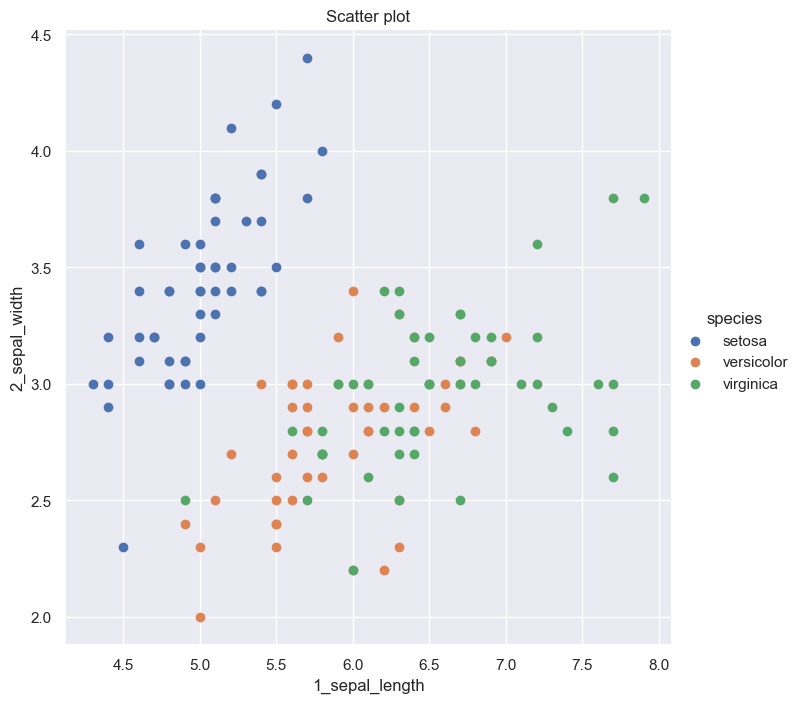

In [2]:
# load the data set
iris = sns.load_dataset("iris")
iris = iris.rename(index = str, columns = {'sepal_length':'1_sepal_length','sepal_width':'2_sepal_width'
                                        , 'petal_length':'3_petal_length', 'petal_width':'4_petal_width'})

# plot the scatter of sepal length vs sepal width
sns.FacetGrid(iris, hue = "species", height = 7).map(plt.scatter, "1_sepal_length", "2_sepal_width").add_legend()
plt.title("Scatter plot")
df1 = iris[["1_sepal_length", "2_sepal_width",'species']]



- Xử lý bằng phương pháp Gaussian Naïve Bayes dùng thư viện Numpy và Pandas

In [3]:
def predict_NB_gaussian_class(X, mu_list, std_list, pi_list):
    # #Trả về lớp mà hàm mục tiêu Naive Bayes Gauss có giá trị lớn nhất
    # Ta sẽ sử dụng thư viện scipy để tính P(x|c) norm.pdf or multivariate_norm.pdf() 
    score_list = []
    classes = len(mu_list)
    for p in range(classes):
        # score la xác suất hậu nhiệm argmax(P(x|c) * P(c)) 
        # norm.pdf(...) Đây là Gaussian probability density function tức là P(xi​∣y=p)
        # Để đơn giản ta chỉ căn cứ vào độ dài cánh hoa để phân loại tức là feature 1 và 2
        # sepal length , sepal width 
        # x[0] feature 1, x[1] feature 2
        # mu_list : mean của P 
        # mu_list[p][0][0] nghĩa là class mean có dạng [[[m1, m2]]] 
        # tương tự std_list 
        # gia định các vecto độc lập với nhau 
        score = (norm.pdf(x = X[0], loc = mu_list[p][0][0], scale = std_list[p][0][0] )
        * norm.pdf(x = X[1], loc = mu_list[p][0][1], scale = std_list[p][0][1] )
        * pi_list[p])
    
        score_list.append(score)

    # np.argmax: trả về vị trí của phần tử có giá trị lớn nhất 
    
    return np.argmax(score_list)

def predict_Bayes_class(X, mu_list, sigma_list):
    # Trả về lớp dự đoán từ optimal bayes classifier 
    # - các phân phối phải được biết trước
    scores_list = []
    classes = len(mu_list)
    # trường hợp các feature có mối liên qua mạnh với nhau, cần cov: ma trận hiệp phương sai 
    # tính P(x∣y=p)
    for p in range(classes):
        score = scipy.stats.multivariate_normal.pdf(X, mean=mu_list[p], cov=sigma_list[p])
        scores_list.append(score)
    return np.argmax(scores_list)
    

- In và vẽ kết quả ra màn hình (chú ý đoạn này có thể phát sinh lỗi do thiếu thư viện)

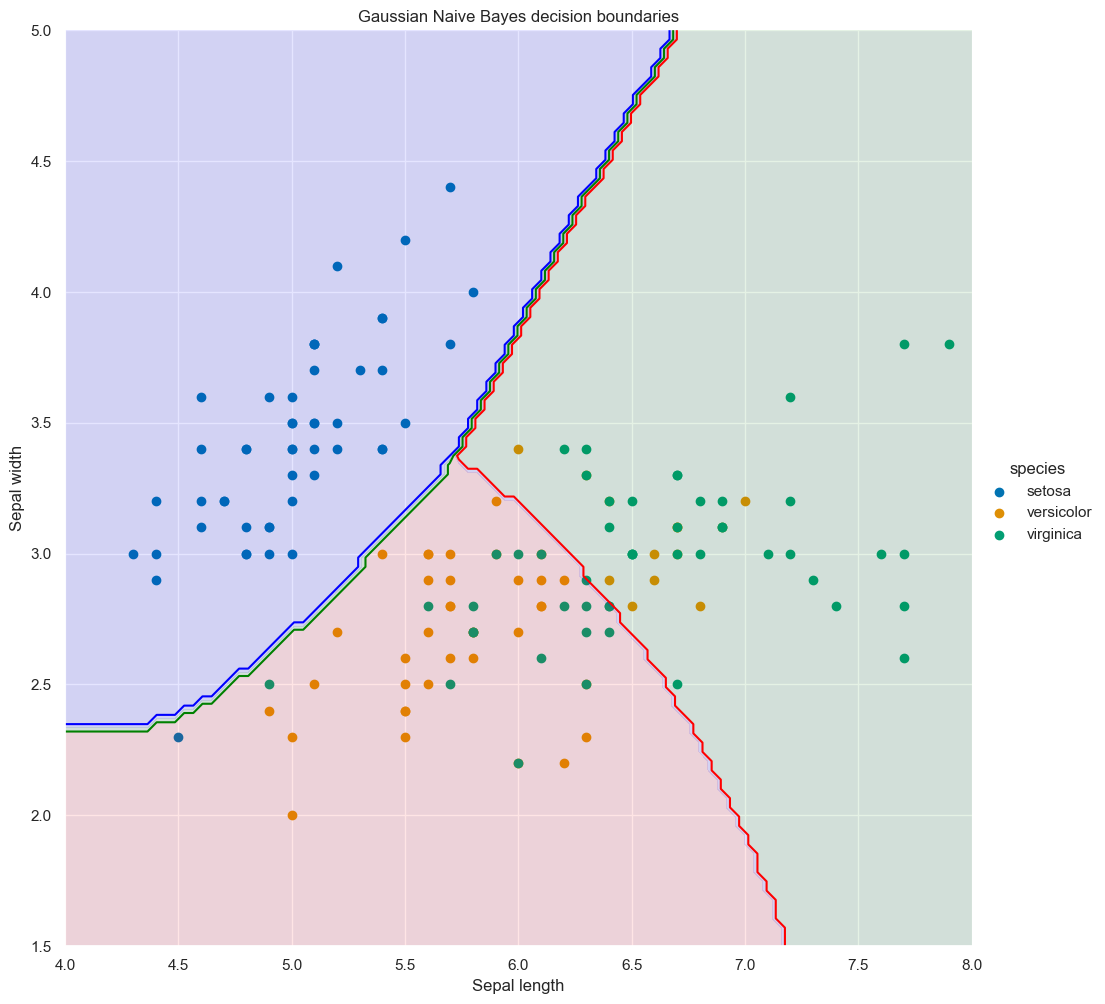

In [ ]:
#Estimating the parameters ( ước tính các tham số, mean, độ lêch chuẩn) 
# [1,2] nghĩa là cắt tại index = 1, index = 2 => cắt thành 3 phần 

mu_list = np.split(df1.groupby('species').mean().values,[1,2])
std_list = np.split(df1.groupby('species').std().values,[1,2], axis = 0)
pi_list = df1.iloc[:,2].value_counts().values / len(df1)

# Our 2-dimensional distribution will be over variables X and Y
# # Phân phối hai chiều của chúng ta sẽ dựa trên các biến X và Y
N = 100
# Tao 100 diem tu 4, 8
X = np.linspace(4, 8, N)
Y = np.linspace(1.5, 5, N)
# tao ma tran x, y 
X, Y = np.meshgrid(X, Y)

# fig = plt.figure(figsize = (10,10))
# ax = fig.gca()
color_list = ['Blues','Greens','Reds']
my_norm = colors.Normalize(vmin=-1.,vmax=1.)
g = sns.FacetGrid(iris, hue="species", height =10, palette = 'colorblind') .map(plt.scatter, "1_sepal_length", "2_sepal_width",) .add_legend()
    
my_ax = g.ax
#Computing the predicted class function for each value on the grid
#Tính toán hàm dự đoán lớp cho mỗi giá trị trên lưới
# X, Y là meshgrid (100x100)

# np.ravel(X) → flatten thành vector 10000 phần tử tương tự với Y 
# zip(...) → tạo từng điểm:

zz = np.array( [predict_NB_gaussian_class( np.array([xx,yy]).reshape(-1,1), mu_list, std_list, pi_list)
for xx, yy in zip(np.ravel(X), np.ravel(Y)) ] )
#Reshaping the predicted class into the meshgrid shape
# #Định hình lại lớp dự đoán thành hình dạng lưới [[]]
Z = zz.reshape(X.shape)
#Plot the filled and boundary contours
# x, y lưới tọa độ, z class tại mỗi điểm, alpha độ trong suốt, màu 

my_ax.contourf( X, Y, Z, 2, alpha = .1, colors = ('blue','green','red'))
my_ax.contour( X, Y, Z, 2, alpha = 1, colors = ('blue','green','red'))
# Addd axis and title
my_ax.set_xlabel('Sepal length')
my_ax.set_ylabel('Sepal width')
my_ax.set_title('Gaussian Naive Bayes decision boundaries')
plt.show()

#### Su dung Scikit-learning 


/tmp/ipykernel_7311/3519553977.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y_labels = df1.iloc[:,2].replace({'setosa':0,'versicolor':1,'virginica':2}).copy()


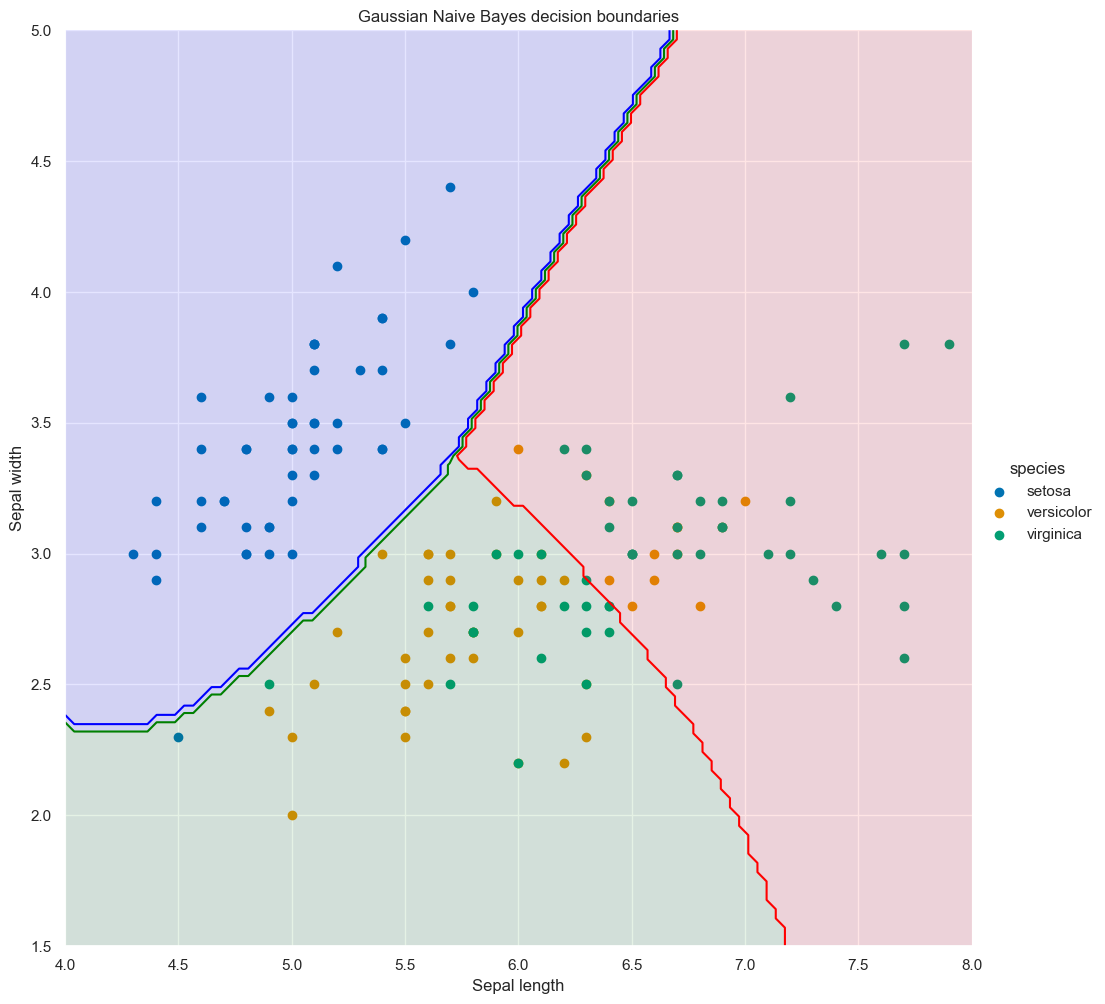

In [11]:
from sklearn.naive_bayes import GaussianNB 

#Setup X and y data
X_data = df1.iloc[:,0:2].values 
y_labels = df1.iloc[:,2].replace({'setosa':0,'versicolor':1,'virginica':2}).copy()

# Fit model 
model_sk = GaussianNB(priors = None) 
model_sk.fit(X_data, y_labels)

# Our 2-dimensional classifier will be over variables X and Y
N = 100
X = np.linspace(4, 8, N)
Y = np.linspace(1.5, 5, N)
X, Y = np.meshgrid(X, Y)


color_list = ['Blues','Greens','Reds']
my_norm = colors.Normalize(vmin=-1.,vmax=1.)
g = sns.FacetGrid(iris, hue="species", height=10, palette = 'colorblind') .map(plt.scatter, "1_sepal_length", "2_sepal_width",) .add_legend()
my_ax = g.ax
#Computing the predicted class function for each value on the grid
zz = np.array( [model_sk.predict( [[xx,yy]])[0] for xx, yy in zip(np.ravel(X), np.ravel(Y)
) ] )
#Reshaping the predicted class into the meshgrid shape
Z = zz.reshape(X.shape)
#Plot the filled and boundary contours
my_ax.contourf( X, Y, Z, 2, alpha = .1, colors = ('blue','green','red'))
my_ax.contour( X, Y, Z, 2, alpha = 1, colors = ('blue','green','red'))
# Addd axis and title
my_ax.set_xlabel('Sepal length')
my_ax.set_ylabel('Sepal width')
my_ax.set_title('Gaussian Naive Bayes decision boundaries')

plt.show()

#### Bai tap mo rong: 
- Hãy mở rộng phần code đã có, để thực hiện phân loại với đầu vào là đủ 04 thuộc tính
của dữ liệu. Chia tập dữ liệu thành train:test theo tỉ lệ 4:1, huấn luyện và dự đoán trên tập test, sau đó tính
độ chính xác theo các chỉ số (độ đo) đã học

### Bai tap tu giai: Mo hinh phan loai Gaussian Navie Bayes 
- Tập dữ liệu phân loại bệnh nhân ung thư vú của Đại học Wisconsin–Madison, Hoa Kỳ tại link:
https://ftp.cs.wisc.edu/math-prog/cpo-dataset/machine-learn/cancer/cancer1/
Để dự đoán một bệnh nhân có khả năng ung thư hay không, người ta thu thập các mẫu sinh thiết, xét
nghiệm bằng việc lấy một lát cắt của mẫu để soi dưới kính hiển vi, quét và ghi lại mẫu dưới dạng các
khung ảnh số của các nhân tế bào. Từ đó, người ta tiến hành đo kích thước, hình dạng, kết cấu của chúng
và tính toán 10 đặc tính của nhân. Cụ thể trong tệp dữ liệu các trường sẽ là
1. Mã số mẫu
2. Loại: 2 cho lành tính, 4 cho ác tính (2 for benign, 4 for malignant)
3. Độ dày hạch (Clump Thickness)
4. Sự đồng nhất của kích thước tế bào (Uniformity of Cell Size)
5. Tính đồng nhất của hình dạng tế bào (Uniformity of Cell Shape)
6. Độ kết dính lề - biên (Marginal Adhesion)
7. Kích thước tế bào biểu mô đơn (Single Epithelial Cell Size)
8. Phần nhân ngoài (Bare Nuclei)
9. Chất nhiễm sắc thể (Bland Chromatin)
10. Nhân trong thường (Normal Nucleoli)
11. Vỏ (Mitoses)
- Tìm hiểu thêm về dữ liệu bằng cách đọc tệp data.doc trong cùng thư mục. Trong số 698 mẫu thu thập (tệp
datacum), người ta chia thành hai nhóm, u lành tính (B–benign) và u ác tính (M–malignant). Hãy tách dữ
liệu thành các phần như sau:
- Chọn 80 mẫu lành tính (Trường phân loại là 2) và 40 mẫu ác tính (Trường phân loại là 4) làm dữ
liệu Test, chúng ta sẽ không sử dụng trường phân loại. Phần còn lại sẽ là dữ liệu training.
- Sử dụng mô hình phân loại Naïve Bayes (chú ý dữ liệu quan sát là biến liên tục – cần chọn phương
pháp phù hợp) để lập chương trình thực hiện phân loại dựa trên dữ liệu training.
- Sau đó thực hiện việc kiểm chứng và so sánh độ chính xác theo các chỉ số Acurracy, Precision và
Recall. Có thể sử dụng thư viện, nhưng cần có giải thích rõ các phần chương trình.

## B. PHƯƠNG PHÁP NÄIVE BAYES CHO DỮ LIỆU RỜI RẠC

### MULTINOMIAL NAÏVE BAYES

#### Vi du 1: 